# Analyzing heart rate 

T-test for 2 groups every other week using RCN and not using. Note this is statistically not correct.

In [9]:
import pandas as pd
import matplotlib as plt
import sklearn as sk
import matplotlib.pyplot as plt

heart_data = pd.read_csv("data/K_Oura_14.4/App Data/heartrate.csv", sep=";")
heart_data["timestamp"] = pd.to_datetime(heart_data["timestamp"])
heart_data["bpm"] = heart_data["bpm"].astype(int)

print(heart_data.head())

heart_data_rest = heart_data[heart_data["source"] == "rest"]
heart_data_rest.head()


                  timestamp  bpm source
0 2026-01-15 13:16:24+00:00   76  awake
1 2026-01-15 13:16:46+00:00   78  awake
2 2026-01-15 13:17:12+00:00   79  awake
3 2026-01-15 13:22:47+00:00   81  awake
4 2026-01-15 13:22:53+00:00   79  awake


,timestamp,bpm,source
168,2026-01-15 18:19:30+00:00,65,rest
169,2026-01-15 18:31:30+00:00,65,rest
170,2026-01-15 18:37:30+00:00,66,rest
257,2026-01-15 21:41:44+00:00,57,rest
258,2026-01-15 21:46:44+00:00,56,rest


In [10]:
# add data labels to the data frame
# 7.2.-13.2.2026 24.2-27.2.2026 7.3.-14.3.2026 1.4.-8.4.2026

utc = "UTC"
intervals = [
    (pd.Timestamp("2026-02-07", tz=utc), pd.Timestamp("2026-02-13", tz=utc)),
    (pd.Timestamp("2026-02-24", tz=utc), pd.Timestamp("2026-02-27", tz=utc)),
    (pd.Timestamp("2026-03-07", tz=utc), pd.Timestamp("2026-03-14", tz=utc)),
    (pd.Timestamp("2026-04-01", tz=utc), pd.Timestamp("2026-04-08", tz=utc)),
]

def generate_labels(timestamp): # label 1 used rcn
    for start, end in intervals:
        if start <= timestamp <= end:
            return 1
    return 0

heart_data["label"] = heart_data["timestamp"].apply(generate_labels)
heart_data_rest["label"] = heart_data_rest["timestamp"].apply(generate_labels)


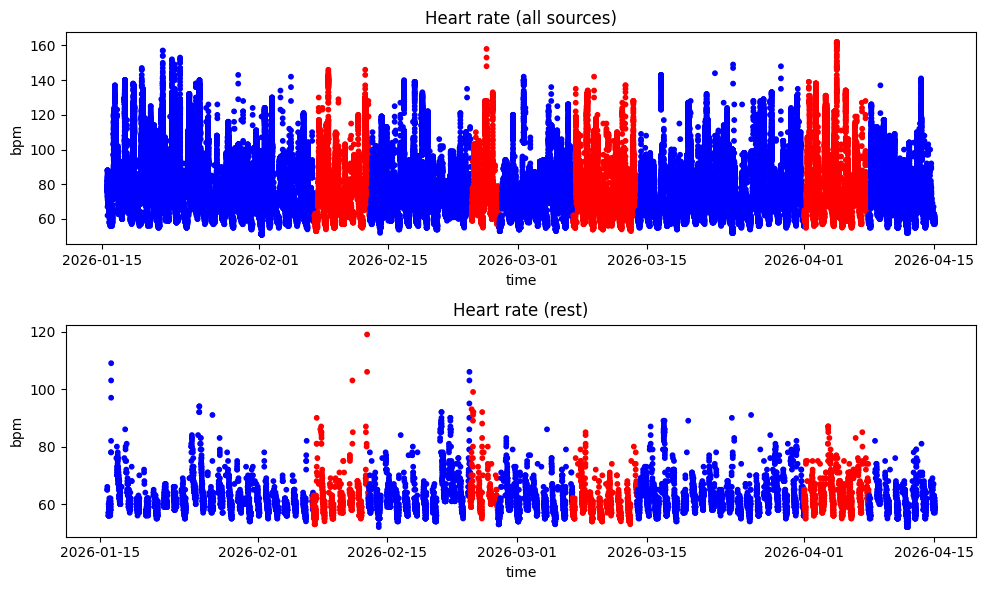

In [11]:
# color the data points based on the label
label_colors = heart_data["label"].map({0: "blue", 1: "red"}).tolist()
rest_label_colors = heart_data_rest["label"].map({0: "blue", 1: "red"}).tolist()

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

axs[0].scatter(heart_data["timestamp"], heart_data["bpm"], c=label_colors, s=10)
axs[0].set_xlabel("time")
axs[0].set_ylabel("bpm")
axs[0].set_title("Heart rate (all sources)")

axs[1].scatter(heart_data_rest["timestamp"], heart_data_rest["bpm"], c=rest_label_colors, s=10)
axs[1].set_xlabel("time")
axs[1].set_ylabel("bpm")
axs[1].set_title("Heart rate (rest)")

fig.tight_layout()


In [12]:
#compare bpm values of two groups with a T-test

from scipy import stats

group1_all = heart_data[(heart_data["label"] == 1) ]["bpm"]
group0_all = heart_data[(heart_data["label"] == 0) ]["bpm"]
t_stat, p_value = stats.ttest_ind(group1_all, group0_all, alternative="two-sided")

print(f"T_statistics all:{t_stat},p-value:{p_value}")


group1 = heart_data[(heart_data["label"] == 1) & (heart_data["source"] == "rest")]["bpm"]
group0 = heart_data[(heart_data["label"] == 0) & (heart_data["source"] == "rest")]["bpm"]
t_stat, p_value = stats.ttest_ind(group1, group0, alternative="two-sided")

print(f"T_statistics at rest:{t_stat},p-value:{p_value}")

T_statistics all:3.0893958233814662,p-value:0.0020061706654244437
T_statistics at rest:-0.013032140947405187,p-value:0.9896024294771681


# Claude code check


Label 1 (RCN) samples after resampling : 86361
Label 0 (control) samples after resampling: 128695

Aligned length (samples): 86361
Approx. duration at 1min resolution: 86361 minutes = 1439.3 hours

Difference series  mean : -1.49 bpm
Difference series  std  : 8.96 bpm


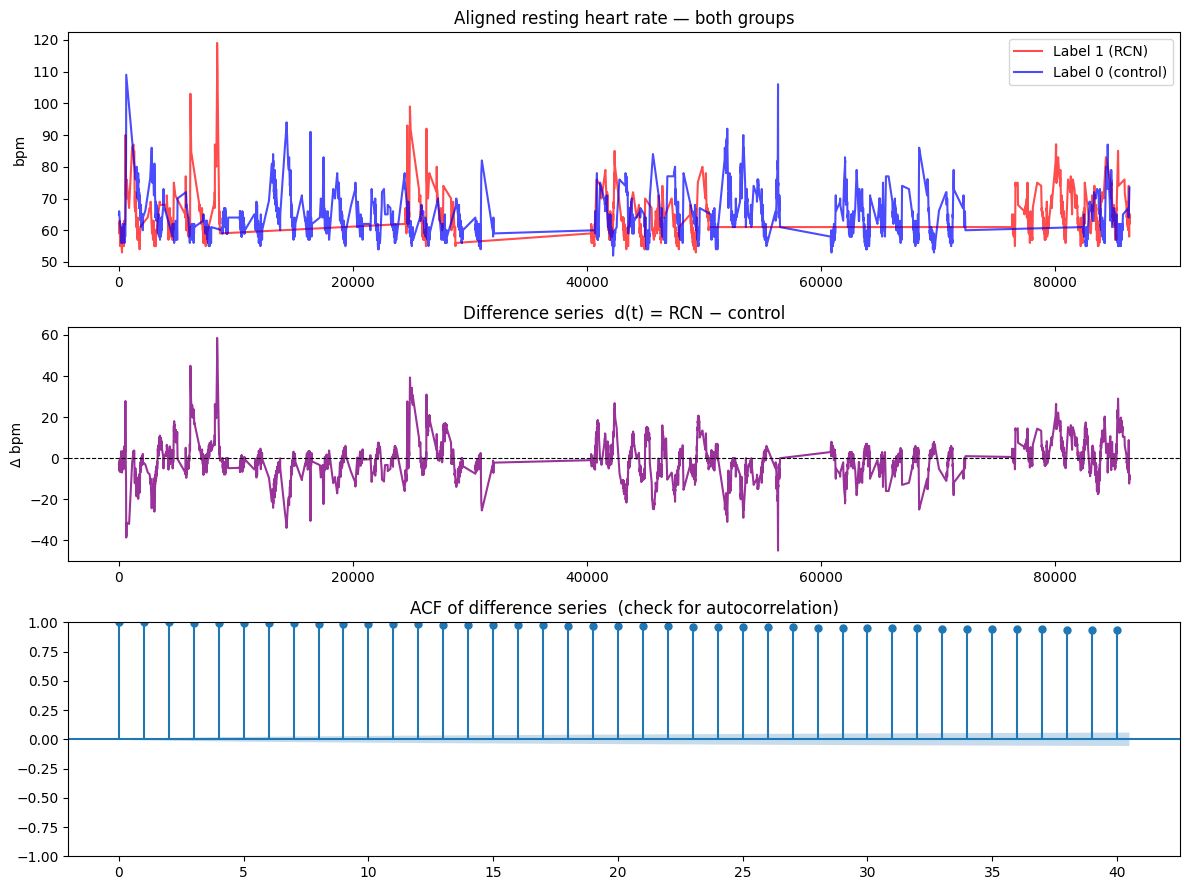


--- Alignment complete ---
Use  g1, g0  for the aligned individual series.
Use  d       for the difference series in Step 2 (GLS / permutation test).


In [13]:
# =============================================================================
# STEP 1: Align label groups to a common time grid before comparison
# =============================================================================
# The two label groups span different calendar periods and have different
# lengths. We resample each to a regular 1-minute grid, then trim both
# to equal length so the difference series d(t) = label1(t) - label0(t)
# is well-defined for time-series methods.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

RESAMPLE_FREQ = "1min"   # change to "5min" if data is sparse

# --- 1a. Separate the two groups (rest source only, same as before) ----------
g1_raw = heart_data_rest[heart_data_rest["label"] == 1][["timestamp", "bpm"]].copy()
g0_raw = heart_data_rest[heart_data_rest["label"] == 0][["timestamp", "bpm"]].copy()

# --- 1b. Resample each group to a regular grid using median per bin ----------
# Using median instead of mean makes this robust to short spikes in HR data.
def to_regular_grid(df, freq=RESAMPLE_FREQ):
    df = df.set_index("timestamp").sort_index()
    resampled = df["bpm"].resample(freq).median()
    resampled = resampled.interpolate(method="time")   # fill any empty bins
    resampled = resampled.dropna()
    # Reset to relative integer index so groups align positionally,
    # not by wall-clock time.
    resampled = resampled.reset_index(drop=True)
    return resampled

g1 = to_regular_grid(g1_raw)
g0 = to_regular_grid(g0_raw)

print(f"Label 1 (RCN) samples after resampling : {len(g1)}")
print(f"Label 0 (control) samples after resampling: {len(g0)}")

# --- 1c. Trim both series to the same length ---------------------------------
min_len = min(len(g1), len(g0))
g1 = g1.iloc[:min_len]
g0 = g0.iloc[:min_len]

print(f"\nAligned length (samples): {min_len}")
print(f"Approx. duration at {RESAMPLE_FREQ} resolution: "
      f"{min_len} minutes = {min_len/60:.1f} hours")

# --- 1d. Compute the difference series ---------------------------------------
d = g1.values - g0.values          # d(t) = HR_rcn(t) - HR_control(t)

print(f"\nDifference series  mean : {d.mean():.2f} bpm")
print(f"Difference series  std  : {d.std():.2f} bpm")

# --- 1e. Visual diagnostics --------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(12, 9))

axs[0].plot(g1.values, color="red",  alpha=0.7, label="Label 1 (RCN)")
axs[0].plot(g0.values, color="blue", alpha=0.7, label="Label 0 (control)")
axs[0].set_ylabel("bpm")
axs[0].set_title("Aligned resting heart rate — both groups")
axs[0].legend()

axs[1].plot(d, color="purple", alpha=0.8)
axs[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axs[1].set_ylabel("Δ bpm")
axs[1].set_title("Difference series  d(t) = RCN − control")

plot_acf(d, ax=axs[2], lags=min(40, min_len // 2 - 1))
axs[2].set_title("ACF of difference series  (check for autocorrelation)")

fig.tight_layout()
plt.show()

# --- Summary for next step ---------------------------------------------------
print("\n--- Alignment complete ---")
print("Use  g1, g0  for the aligned individual series.")
print("Use  d       for the difference series in Step 2 (GLS / permutation test).")

RCN days     : 23
Control days : 68

RCN     median: 60.0 bpm  (IQR 59.0–62.0)
Control median: 60.0 bpm  (IQR 59.0–62.0)

Mann-Whitney U : 783.0
p-value        : 0.9963
Effect size r  : -0.001  (|r|>0.1 small, >0.3 medium, >0.5 large)
→ No significant difference detected (p ≥ 0.05)


C:\Users\henri\AppData\Local\Temp\ipykernel_29936\217708044.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0].boxplot([g0_daily, g1_daily], labels=["Control", "RCN"], patch_artist=True,


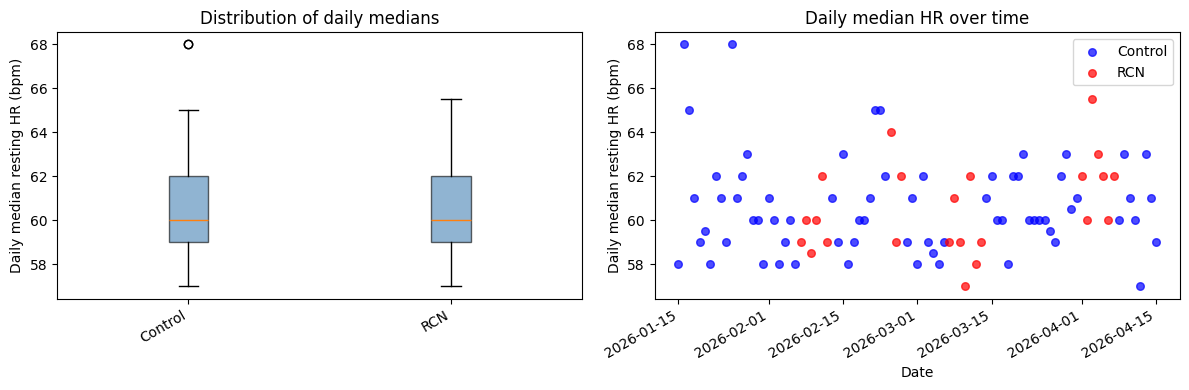

In [17]:
# =============================================================================
# STEP 3 (revised): Compare daily median resting HR between groups
# =============================================================================
# Aggregate to one value per day per group, then use a Mann-Whitney U test.
# Daily medians are approximately independent, removing the autocorrelation
# problem entirely. No alignment needed — each day stands on its own.

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# --- 3a. Daily median resting HR per label -----------------------------------
daily = (heart_data_rest
         .groupby([heart_data_rest["timestamp"].dt.date, "label"])["bpm"]
         .median()
         .reset_index())
daily.columns = ["date", "label", "median_bpm"]

g1_daily = daily[daily["label"] == 1]["median_bpm"].values
g0_daily = daily[daily["label"] == 0]["median_bpm"].values

print(f"RCN days     : {len(g1_daily)}")
print(f"Control days : {len(g0_daily)}")
print(f"\nRCN     median: {np.median(g1_daily):.1f} bpm  (IQR {np.percentile(g1_daily,25):.1f}–{np.percentile(g1_daily,75):.1f})")
print(f"Control median: {np.median(g0_daily):.1f} bpm  (IQR {np.percentile(g0_daily,25):.1f}–{np.percentile(g0_daily,75):.1f})")

# --- 3b. Mann-Whitney U test --------------------------------------------------
# Non-parametric, no normality assumption, works on small samples,
# and daily medians are reasonably independent.
stat, p_value = stats.mannwhitneyu(g1_daily, g0_daily, alternative="two-sided")
r = 1 - (2 * stat) / (len(g1_daily) * len(g0_daily))  # rank-biserial correlation (effect size)

print(f"\nMann-Whitney U : {stat:.1f}")
print(f"p-value        : {p_value:.4f}")
print(f"Effect size r  : {r:+.3f}  (|r|>0.1 small, >0.3 medium, >0.5 large)")

if p_value < 0.05:
    print("→ Significant difference between RCN and control days (p < 0.05)")
else:
    print("→ No significant difference detected (p ≥ 0.05)")

# --- 3c. Plot ----------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot
axs[0].boxplot([g0_daily, g1_daily], labels=["Control", "RCN"], patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6))
axs[0].set_ylabel("Daily median resting HR (bpm)")
axs[0].set_title("Distribution of daily medians")

# Daily values over time
rcn_dates  = daily[daily["label"] == 1]["date"]
ctrl_dates = daily[daily["label"] == 0]["date"]
axs[1].scatter(ctrl_dates, g0_daily, color="blue", alpha=0.7, label="Control", s=30)
axs[1].scatter(rcn_dates,  g1_daily, color="red",  alpha=0.7, label="RCN",     s=30)
axs[1].set_xlabel("Date")
axs[1].set_ylabel("Daily median resting HR (bpm)")
axs[1].set_title("Daily median HR over time")
axs[1].legend()
fig.autofmt_xdate()

fig.tight_layout()
plt.show()

In [18]:
from scipy.stats import levene
stat, p = levene(g1_daily, g0_daily)
print(f"Levene test for equal variance: p={p:.4f}")

print(f"RCN std    : {np.std(g1_daily):.2f} bpm")
print(f"Control std: {np.std(g0_daily):.2f} bpm")

Levene test for equal variance: p=0.9275
RCN std    : 2.02 bpm
Control std: 2.21 bpm


# Step 1 and 3 for complete data set

# Fitting linear mixed model to resting data

                     count   mean    std    min    25%    50%    75%     max
label interval_id                                                           
0     ctrl_1        8635.0  67.08  10.45  55.00  60.45  63.00  70.83  109.00
      ctrl_10       4320.0  60.46   0.12  60.24  60.35  60.46  60.56   60.67
      ctrl_11      10076.0  64.38   6.51  54.00  60.72  60.96  67.00   89.00
      ctrl_12      10040.0  66.55   7.19  55.00  61.24  64.57  70.25   90.00
      ctrl_13       8635.0  69.81   7.88  54.00  62.74  70.00  75.82   91.00
      ctrl_14       4320.0  59.43   2.25  56.00  58.72  58.83  58.94   72.23
      ctrl_15      10076.0  61.55   5.61  55.00  58.21  58.46  63.60   82.00
      ctrl_16       6451.0  64.54   5.88  52.00  60.08  64.31  66.94   81.00
      ctrl_2        4320.0  62.85   2.98  55.00  60.80  63.23  64.00   75.52
      ctrl_3       10076.0  66.72   6.99  54.00  62.00  65.00  70.19   94.00
      ctrl_4       10040.0  63.11   5.23  54.00  59.08  61.81  65.57   82.00

c:\Users\henri\Documents\PythonCodes\Aalto_projects\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


              Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   bpm         
No. Observations:    161766    Method:               REML        
No. Groups:          20        Scale:                45.1434     
Min. group size:     4320      Log-Likelihood:       -537779.3673
Max. group size:     10076     Converged:            Yes         
Mean group size:     8088.3                                      
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              64.233    0.804 79.849 0.000 62.657 65.810
label[T.1]              2.976    1.799  1.655 0.098 -0.549  6.502
time_within             0.000    0.000  3.511 0.000  0.000  0.000
label[T.1]:time_within  0.000    0.000 10.003 0.000  0.000  0.000
Group Var              10.334    0.666                           


=== Fixed effects ===


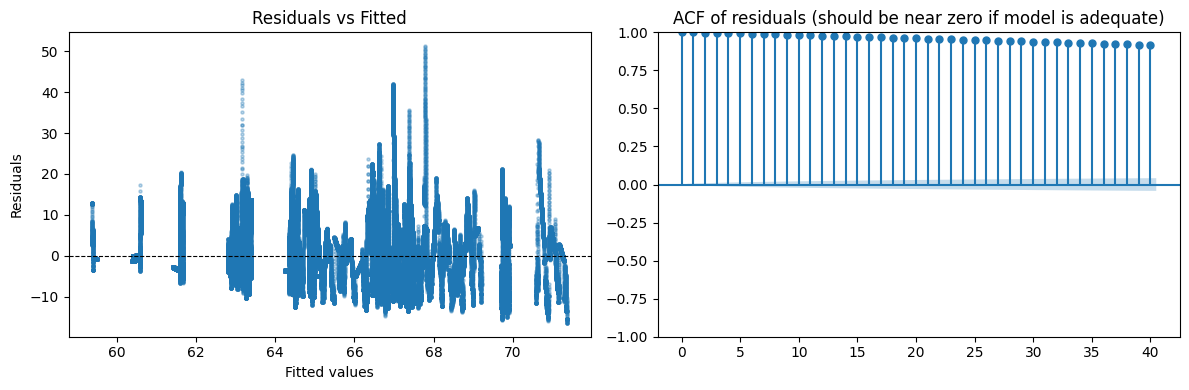

In [7]:
# =============================================================================
# STEP 2: Linear Mixed Model
# =============================================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.regression.linear_model import GLS
import matplotlib.pyplot as plt

# --- 2a. Build a long-format DataFrame from the aligned series ---------------
# Each row = one time point, with columns: bpm, label, time_within, interval_id

def build_lmm_df(heart_data_rest, intervals, resample_freq="1min"):
    segments = []

    # Label 1 intervals (RCN)
    for i, (start, end) in enumerate(intervals):
        seg = heart_data_rest[
            (heart_data_rest["timestamp"] >= start) &
            (heart_data_rest["timestamp"] <= end)
        ][["timestamp", "bpm"]].copy()
        seg = seg.set_index("timestamp").resample(resample_freq).median()
        seg = seg.interpolate(method="time").dropna().reset_index()
        seg["label"] = 1
        seg["interval_id"] = f"rcn_{i+1}"
        seg["time_within"] = np.arange(len(seg))   # relative time 0,1,2,...
        segments.append(seg)

    # Label 0 intervals — everything outside RCN periods, split into
    # matched-length chunks so each has a paired interval_id
    all_start = heart_data_rest["timestamp"].min()
    all_end   = heart_data_rest["timestamp"].max()

    control_mask = heart_data_rest["label"] == 0
    ctrl = heart_data_rest[control_mask][["timestamp", "bpm"]].copy()
    ctrl = ctrl.set_index("timestamp").resample(resample_freq).median()
    ctrl = ctrl.interpolate(method="time").dropna().reset_index()

    # Split control into chunks equal in length to each RCN interval
    offset = 0
    for i, rcn_seg in enumerate(segments):
        n = len(rcn_seg)
        chunk = ctrl.iloc[offset:offset + n].copy()
        if len(chunk) == 0:
            break
        chunk["label"] = 0
        chunk["interval_id"] = f"ctrl_{i+1}"
        chunk["time_within"] = np.arange(len(chunk))
        segments.append(chunk)
        offset += n

    df = pd.concat(segments, ignore_index=True)
    df["label"] = df["label"].astype("category")
    return df

df_lmm = build_lmm_df(heart_data_rest, intervals)

print(df_lmm.groupby(["label", "interval_id"])["bpm"].describe().round(2))

# --- 2b. Fit the LMM ---------------------------------------------------------
# Fixed effects  : label (group), time_within, label:time_within interaction
# Random effect  : interval_id — captures that each interval has its own
#                  baseline HR (e.g. seasonal variation, fitness changes)
#
# OPTION A: Treat each interval as a random intercept (recommended)
# This accounts for interval-to-interval baseline variation.

model = smf.mixedlm(
    "bpm ~ label + time_within + label:time_within",
    data=df_lmm,
    groups=df_lmm["interval_id"],      # random intercept per interval
)
result = model.fit(method="lbfgs")
print(result.summary())

# --- 2c. Key results to look at ----------------------------------------------
print("\n=== Fixed effects ===")
print(result.fe_params)

print("\n=== p-values ===")
print(result.pvalues)

# --- 2d. Residual diagnostics ------------------------------------------------
residuals = result.resid

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].scatter(result.fittedvalues, residuals, alpha=0.3, s=5)
axs[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axs[0].set_xlabel("Fitted values")
axs[0].set_ylabel("Residuals")
axs[0].set_title("Residuals vs Fitted")

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, ax=axs[1], lags=40)
axs[1].set_title("ACF of residuals (should be near zero if model is adequate)")

fig.tight_layout()
plt.show()

# Testing full data

Label 1 (RCN) samples after resampling : 86394
Label 0 (control) samples after resampling: 128998

Aligned length (samples): 86394
Approx. duration at 1min resolution: 86394 minutes = 1439.9 hours

Difference series  mean : -3.65 bpm
Difference series  std  : 15.18 bpm


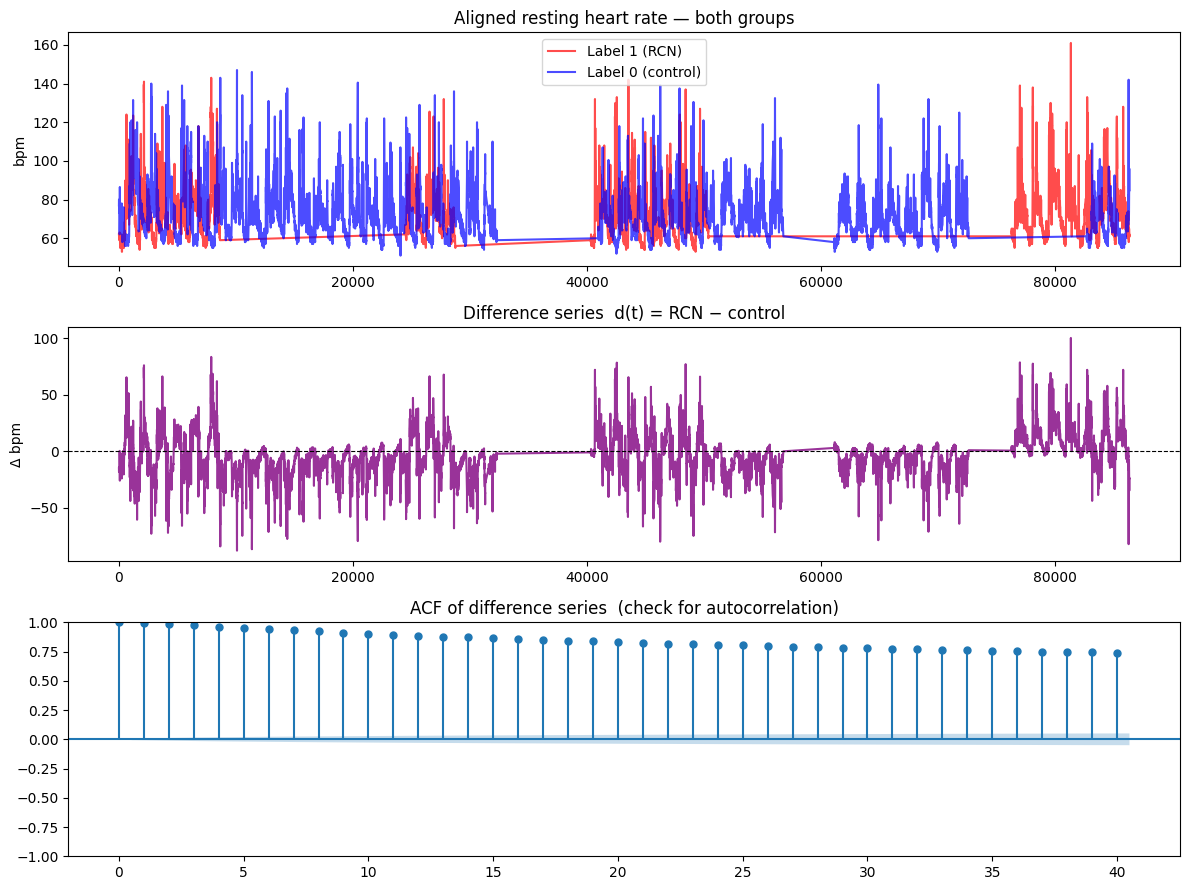


--- Alignment complete ---
Use  g1_raw_full, g0_raw_full  for the aligned individual series.
Use  d_full   for the difference series in Step 2 (GLS / permutation test).


In [19]:
# =============================================================================
# Full data set
# STEP 1: Align label groups to a common time grid before comparison
# =============================================================================
# The two label groups span different calendar periods and have different
# lengths. We resample each to a regular 1-minute grid, then trim both
# to equal length so the difference series d(t) = label1(t) - label0(t)
# is well-defined for time-series methods.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

RESAMPLE_FREQ = "1min"   # change to "5min" if data is sparse

# --- 1a. Separate the two groups (rest source only, same as before) ----------
g1_raw_full = heart_data[heart_data["label"] == 1][["timestamp", "bpm"]].copy()
g0_raw_full = heart_data[heart_data["label"] == 0][["timestamp", "bpm"]].copy()

# --- 1b. Resample each group to a regular grid using median per bin ----------
# Using median instead of mean makes this robust to short spikes in HR data.
def to_regular_grid(df, freq=RESAMPLE_FREQ):
    df = df.set_index("timestamp").sort_index()
    resampled = df["bpm"].resample(freq).median()
    resampled = resampled.interpolate(method="time")   # fill any empty bins
    resampled = resampled.dropna()
    # Reset to relative integer index so groups align positionally,
    # not by wall-clock time.
    resampled = resampled.reset_index(drop=True)
    return resampled

g1_raw_full = to_regular_grid(g1_raw_full)
g0_raw_full = to_regular_grid(g0_raw_full)

print(f"Label 1 (RCN) samples after resampling : {len(g1_raw_full)}")
print(f"Label 0 (control) samples after resampling: {len(g0_raw_full)}")

# --- 1c. Trim both series to the same length ---------------------------------
min_len = min(len(g1_raw_full), len(g0_raw_full))
g1_raw_full = g1_raw_full.iloc[:min_len]
g0_raw_full = g0_raw_full.iloc[:min_len]

print(f"\nAligned length (samples): {min_len}")
print(f"Approx. duration at {RESAMPLE_FREQ} resolution: "
      f"{min_len} minutes = {min_len/60:.1f} hours")

# --- 1d. Compute the difference series ---------------------------------------
d_full = g1_raw_full.values - g0_raw_full.values          # d(t) = HR_rcn(t) - HR_control(t)

print(f"\nDifference series  mean : {d_full.mean():.2f} bpm")
print(f"Difference series  std  : {d_full.std():.2f} bpm")

# --- 1e. Visual diagnostics --------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(12, 9))

axs[0].plot(g1_raw_full.values, color="red",  alpha=0.7, label="Label 1 (RCN)")
axs[0].plot(g0_raw_full.values, color="blue", alpha=0.7, label="Label 0 (control)")
axs[0].set_ylabel("bpm")
axs[0].set_title("Aligned resting heart rate — both groups")
axs[0].legend()

axs[1].plot(d_full, color="purple", alpha=0.8)
axs[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axs[1].set_ylabel("Δ bpm")
axs[1].set_title("Difference series  d(t) = RCN − control")

plot_acf(d_full, ax=axs[2], lags=min(40, min_len // 2 - 1))
axs[2].set_title("ACF of difference series  (check for autocorrelation)")

fig.tight_layout()
plt.show()

# --- Summary for next step ---------------------------------------------------
print("\n--- Alignment complete ---")
print("Use  g1_raw_full, g0_raw_full  for the aligned individual series.")
print("Use  d_full   for the difference series in Step 2 (GLS / permutation test).")

RCN days     : 23
Control days : 68

RCN     median: 85.0 bpm  (IQR 82.0–89.0)
Control median: 85.0 bpm  (IQR 77.8–89.2)

Mann-Whitney U : 806.0
p-value        : 0.8299
Effect size r  : -0.031  (|r|>0.1 small, >0.3 medium, >0.5 large)
→ No significant difference detected (p ≥ 0.05)


C:\Users\henri\AppData\Local\Temp\ipykernel_29936\1360251680.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0].boxplot([g0_daily, g1_daily], labels=["Control", "RCN"], patch_artist=True,


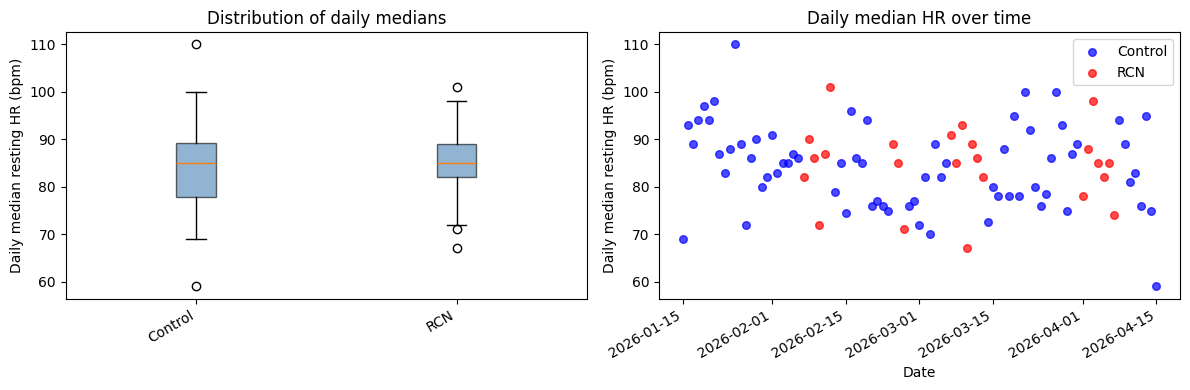

In [21]:
# =============================================================================
# STEP 3 (revised): Compare daily median resting HR between groups
# =============================================================================
# Aggregate to one value per day per group, then use a Mann-Whitney U test.
# Daily medians are approximately independent, removing the autocorrelation
# problem entirely. No alignment needed — each day stands on its own.

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# --- 3a. Daily median resting HR per label -----------------------------------
daily = (heart_data
         .groupby([heart_data["timestamp"].dt.date, "label"])["bpm"]
         .median()
         .reset_index())
daily.columns = ["date", "label", "median_bpm"]

g1_daily = daily[daily["label"] == 1]["median_bpm"].values
g0_daily = daily[daily["label"] == 0]["median_bpm"].values

print(f"RCN days     : {len(g1_daily)}")
print(f"Control days : {len(g0_daily)}")
print(f"\nRCN     median: {np.median(g1_daily):.1f} bpm  (IQR {np.percentile(g1_daily,25):.1f}–{np.percentile(g1_daily,75):.1f})")
print(f"Control median: {np.median(g0_daily):.1f} bpm  (IQR {np.percentile(g0_daily,25):.1f}–{np.percentile(g0_daily,75):.1f})")

# --- 3b. Mann-Whitney U test --------------------------------------------------
# Non-parametric, no normality assumption, works on small samples,
# and daily medians are reasonably independent.
stat, p_value = stats.mannwhitneyu(g1_daily, g0_daily, alternative="two-sided")
r = 1 - (2 * stat) / (len(g1_daily) * len(g0_daily))  # rank-biserial correlation (effect size)

print(f"\nMann-Whitney U : {stat:.1f}")
print(f"p-value        : {p_value:.4f}")
print(f"Effect size r  : {r:+.3f}  (|r|>0.1 small, >0.3 medium, >0.5 large)")

if p_value < 0.05:
    print("→ Significant difference between RCN and control days (p < 0.05)")
else:
    print("→ No significant difference detected (p ≥ 0.05)")

# --- 3c. Plot ----------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot
axs[0].boxplot([g0_daily, g1_daily], labels=["Control", "RCN"], patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6))
axs[0].set_ylabel("Daily median resting HR (bpm)")
axs[0].set_title("Distribution of daily medians")

# Daily values over time
rcn_dates  = daily[daily["label"] == 1]["date"]
ctrl_dates = daily[daily["label"] == 0]["date"]
axs[1].scatter(ctrl_dates, g0_daily, color="blue", alpha=0.7, label="Control", s=30)
axs[1].scatter(rcn_dates,  g1_daily, color="red",  alpha=0.7, label="RCN",     s=30)
axs[1].set_xlabel("Date")
axs[1].set_ylabel("Daily median resting HR (bpm)")
axs[1].set_title("Daily median HR over time")
axs[1].legend()
fig.autofmt_xdate()

fig.tight_layout()
plt.show()

In [22]:
from scipy.stats import levene
stat, p = levene(g1_daily, g0_daily)
print(f"Levene test for equal variance: p={p:.4f}")

print(f"RCN std    : {np.std(g1_daily):.2f} bpm")
print(f"Control std: {np.std(g0_daily):.2f} bpm")

Levene test for equal variance: p=0.3568
RCN std    : 8.02 bpm
Control std: 8.83 bpm
